
# เรียกใช้การอนุมาน DLESyM

deterministic inference workflow พื้นฐานสำหรับรุ่น DLESyM

ตัวอย่างนี้จะสาธิตวิธีการรัน inference workflow อย่างง่ายด้วย
โมเดล DLESyM ซึ่งแตกต่างจากโมเดลพยากรณ์โรคอื่นๆ ใน Earth2studio
DLESyM ทำการสร้างโมเดลระบบโลกทั่วโลก รวมถึงบรรยากาศและมหาสมุทร
องค์ประกอบที่พัฒนาในช่วงเวลาที่แตกต่างกัน (ความละเอียดทางโลกที่แตกต่างกัน)
ภายใน โมเดลใช้ความละเอียด HEALPix nside=64 (ประมาณ 1 องศา)
ตารางสำหรับตัวแปรทางกายภาพที่น่าสนใจ โมเดลยังใช้อินพุตที่ได้รับมาบางส่วนด้วย
ตัวแปรที่ไม่ได้มาจากแหล่งข้อมูลมาตรฐานแต่สามารถคำนวณได้
จากตัวแปรมาตรฐาน

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีสร้างอินสแตนซ์ของโมเดล DLESyM
- วิธีใช้โมเดล API เพื่อสร้าง forecast
- วิธีใช้การเลือกเอาต์พุตและวิธีการกริดซ้ำเพื่อเลือกข้อมูลที่เหมาะสม
- วิธีใช้โมเดล DLESyMLatLon กับ Earth2studio workflows


In [1]:
# /// script
# dependencies = [
#   "earth2studio[dlesym] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
ขั้นตอนแรกคือการดึงข้อมูลอินพุตที่เหมาะสมสำหรับโมเดล แหล่งข้อมูล ERA5
ใน Earth2studio ให้ข้อมูลบนตาราง lat/lon ดังนั้นมีสองตัวเลือก:

- ใช้รุ่น :py:class:`earth2studio.models.px.DLESyMLatLon` DLESyM เวอร์ชันนี้
ยอมรับอินพุตบนตาราง lat/lon และบันทึกลงในตาราง HEALPix ภายใน
ก่อนที่จะส่งคืนเอาต์พุตที่กลับคืนสู่ตาราง lat/lon นี่คือ
แนวทางที่แนะนำสำหรับผู้ใช้ส่วนใหญ่เนื่องจากสามารถใช้กับ Earth2studio ได้โดยตรง
แหล่งข้อมูลและ workflow เนื่องจากดำเนินการกริดใหม่และการประมวลผลล่วงหน้า
ภายใน
- ใช้โมเดล :py:class:`earth2studio.models.px.DLESyM` และจัดการการกริดใหม่
ป้อนข้อมูล lat/lon ด้วยตัวเอง เนื่องจากตัวแบบใช้ตัวแปรที่ได้รับมาบางตัวซึ่ง
ไม่ได้มาจากแหล่งข้อมูล เราก็จะต้องจัดเตรียมข้อมูลที่ได้รับมาเหล่านี้ด้วย
ตัวแปรตัวเราเอง

มาโหลดทั้งสองโมเดลนี้กันและตรวจสอบพิกัดอินพุตที่คาดหวังสำหรับแต่ละรายการ
นอกจากนี้ ให้สังเกตชุดตัวแปรอินพุตและเอาต์พุตสำหรับแต่ละรุ่นด้วย



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป
import numpy as np
import torch

from earth2studio.data import ARCO
from earth2studio.data.utils import fetch_data
from earth2studio.models.px.dlesym import DLESyM, DLESyMLatLon

device = "cuda"
if not torch.cuda.is_available():
    raise RuntimeError("GPU/CUDA required for DLESyM")

# สร้างแหล่งข้อมูล
data = ARCO()

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
# เราจะสร้างอินสแตนซ์ของโมเดลทั้งสองเวอร์ชันเพื่อสาธิตการใช้งานของแต่ละเวอร์ชัน
package = DLESyMLatLon.load_default_package()
model_ll = DLESyMLatLon.load_model(package).to(device)
package = DLESyM.load_default_package()
model_hpx = DLESyM.load_model(package).to(device)

in_coords_ll = model_ll.input_coords()
in_coords_hpx = model_hpx.input_coords()
print(
    "DLESyM LatLon input coord shapes: ",
    [(k, v.shape) for k, v in in_coords_ll.items()],
)
print(
    "DLESyM HPX input coord shapes: ", [(k, v.shape) for k, v in in_coords_hpx.items()]
)
print("Lat-lon input variable names: ", in_coords_ll["variable"])
print(
    "Lat-lon output variable names: ", model_ll.output_coords(in_coords_ll)["variable"]
)
print("HEALPix input variable names: ", in_coords_hpx["variable"])
print(
    "HEALPix output variable names: ",
    model_hpx.output_coords(in_coords_hpx)["variable"],
)

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature
2026-04-25 20:03:37.701 | DEBUG    | earth2studio.data.arco:_async_init:131 - Using Multi-Storage Client for ARCO data access


DLESyM LatLon input coord shapes:  [('batch', (0,)), ('time', (0,)), ('lead_time', (9,)), ('variable', (11,)), ('lat', (721,)), ('lon', (1440,))]
DLESyM HPX input coord shapes:  [('batch', (0,)), ('time', (0,)), ('lead_time', (9,)), ('variable', (9,)), ('face', (12,)), ('height', (64,)), ('width', (64,))]
Lat-lon input variable names:  ['z500' 'z1000' 't2m' 'tcwv' 't850' 'z250' 'sst' 'u10m' 'v10m' 'z300'
 'z700']
Lat-lon output variable names:  ['z500' 'tau300-700' 'z1000' 't2m' 'tcwv' 't850' 'z250' 'ws10m' 'sst']
HEALPix input variable names:  ['z500' 'tau300-700' 'z1000' 't2m' 'tcwv' 't850' 'z250' 'ws10m' 'sst']
HEALPix output variable names:  ['z500' 'tau300-700' 'z1000' 't2m' 'tcwv' 't850' 'z250' 'ws10m' 'sst']


## ทำการทำนาย การลงทะเบียนใหม่ และการเลือกเอาท์พุต
ตอนนี้เรามาดึงข้อมูลตัวอย่างและคาดการณ์ด้วยโมเดลกัน ในฐานะที่เป็น
แหล่งข้อมูลให้ข้อมูล lat/lon เราสามารถใช้โมเดล :py:class:`earth2studio.models.px.DLESyMLatLon` ได้

นอกจากนี้ เรายังสาธิตวิธีการใช้ยูทิลิตี้ regridding ที่จัดทำโดย
`DLESyMLatLon` เพื่อบันทึกลงในตาราง HEALPix :py:class:`earth2studio.models.px.DLESyM`
จากนั้นสามารถใช้โมเดลโดยตรงกับข้อมูล HEALPix

สุดท้าย ลักษณะสำคัญของโมเดล DLESyM ก็คือการคาดการณ์บรรยากาศ
และส่วนประกอบของมหาสมุทรในช่วงเวลาที่ต่างกัน เนื่องจากบรรยากาศมีการพัฒนาเร็วขึ้น
มากกว่ามหาสมุทร คาดการณ์บรรยากาศทุกๆ 6 ชั่วโมง ขณะที่มหาสมุทรเท่านั้น
ทำนายทุก 48 ชั่วโมง ดังนั้น เอาต์พุต lead time ไม่ใช่ทั้งหมดจะใช้ได้กับมหาสมุทร
ส่วนประกอบ. เพื่อความสะดวก เราสามารถใช้วิธีการเลือกเฉพาะผลลัพธ์ที่ถูกต้องได้
สำหรับแต่ละบรรยากาศและองค์ประกอบของมหาสมุทร



In [3]:
ic_date = np.datetime64("2021-06-15")

# ดึงข้อมูลตัวอย่างบางส่วน
x, coords = fetch_data(
    source=data,
    time=np.array([ic_date]),
    variable=np.array(in_coords_ll["variable"]),
    lead_time=in_coords_ll["lead_time"],
    device=device,
)

# สามารถเรียกโมเดล `DLESyMLatLon` ได้โดยตรงกับข้อมูล Lat/lon อินพุต
y, y_coords = model_ll(x, coords)

# หรือเราสามารถใช้ยูทิลิตีการประมวลผลล่วงหน้าและการลงทะเบียนใหม่เพื่อลงทะเบียนข้อมูลใหม่
# ตาราง HEALPix จากนั้นรันโดยตรงกับ `DLESyM` ซึ่งคาดว่าจะได้รับข้อมูล HEALPix
x_prep, coords_prep = model_ll._prepare_derived_variables(x, coords)
x_hpx, coords_hpx = model_ll.to_hpx(x_prep), model_ll.coords_to_hpx(coords_prep)
y_hpx, y_coords_hpx = model_hpx(x_hpx, coords_hpx)

# รับผลลัพธ์ที่ถูกต้องสำหรับส่วนประกอบของบรรยากาศ/มหาสมุทรจากการทำนาย
y_atmos, y_atmos_coords = model_ll.retrieve_valid_atmos_outputs(y, y_coords)
y_ocean, y_ocean_coords = model_ll.retrieve_valid_ocean_outputs(y, y_coords)

print(
    "Atmosphere outputs (variables, lead_time [hrs]):",
    y_atmos_coords["variable"],
    y_atmos_coords["lead_time"].astype("timedelta64[h]"),
)
print(
    "Ocean outputs (variables, lead_time [hrs]):",
    y_ocean_coords["variable"],
    y_ocean_coords["lead_time"].astype("timedelta64[h]"),
)

Fetching ARCO data:   0%|          | 0/11 [00:00<?, ?it/s]

2026-04-25 20:03:52.165 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t850 at 2021-06-13T00:00:00
2026-04-25 20:03:52.166 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: sst at 2021-06-13T00:00:00
2026-04-25 20:03:52.167 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: u10m at 2021-06-13T00:00:00
2026-04-25 20:03:52.168 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t2m at 2021-06-13T00:00:00
2026-04-25 20:03:52.169 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: v10m at 2021-06-13T00:00:00
2026-04-25 20:03:52.170 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z500 at 2021-06-13T00:00:00
2026-04-25 20:03:52.171 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z300 at 2021-06

Fetching ARCO data:   0%|          | 0/11 [00:00<?, ?it/s]

2026-04-25 20:03:52.436 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/sea_surface_temperature/1064592.0.0 to local cache
2026-04-25 20:03:52.464 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_u_component_of_wind/1064592.0.0 to local cache
2026-04-25 20:03:52.514 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/geopotential/1064592.0.0.0 to local cache
2026-04-25 20:03:52.524 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_v_component_of_wind/1064592.0.0 to local cache
2026-04-25 20:03:52.540 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/

Fetching ARCO data:   0%|          | 0/11 [00:01<?, ?it/s]

...

2026-04-25 20:05:38.638 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/geopotential/1064640.0.0.0 to local cache
2026-04-25 20:05:38.682 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/geopotential/1064640.0.0.0 to local cache


Fetching ARCO data:   0%|          | 0/11 [00:01<?, ?it/s]

2026-04-25 20:05:38.857 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/geopotential/1064640.0.0.0 to local cache


Fetching ARCO data: 100%|██████████| 11/11 [00:12<00:00,  1.14s/it]


Atmosphere outputs (variables, lead_time [hrs]): ['z500' 'tau300-700' 'z1000' 't2m' 'tcwv' 't850' 'z250' 'ws10m'] [ 6 12 18 24 30 36 42 48 54 60 66 72 78 84 90 96]
Ocean outputs (variables, lead_time [hrs]): ['sst'] [48 96]


## การวนซ้ำโมเดลเพื่อการคาดการณ์ที่ยาวนานขึ้น
เช่นเดียวกับโมเดลอื่นๆ ใน Earth2studio เราสามารถใช้ตัววนซ้ำโมเดลเพื่อวนซ้ำได้
มากกว่าเอาต์พุต forecasted ขั้นตอนเดียวของโมเดล DLESyM ทำให้เกิดการคาดการณ์
นานกว่า 4 วัน (96 ชั่วโมง) ดังนั้นเพื่อสร้าง forecast นอกฤดูกาล เราสามารถดำเนินการได้ 15 ขั้นตอน
รวมเป็น 60 วัน



In [4]:
n_steps = 16
model_iter_ll = model_ll.create_iterator(x, coords)

for i in range(n_steps):
    x, x_coords = next(model_iter_ll)
    if i > 0:  # อย่าดึงข้อมูลขั้นตอนแรกเนื่องจากเป็นเงื่อนไขเริ่มต้น
        x_atmos, x_atmos_coords = model_ll.retrieve_valid_atmos_outputs(x, x_coords)
        x_ocean, x_ocean_coords = model_ll.retrieve_valid_ocean_outputs(x, x_coords)

print(f"Completed forecast with {n_steps} steps")

Completed forecast with 16 steps


## การใช้เวิร์กโฟลว์ที่กำหนดในตัว
เนื่องจากโมเดล `DLESyMLatLon` อนุญาตให้ใช้ข้อมูลที่มาจากไฟล์โดยตรง
แหล่งข้อมูล Earth2studio เราสามารถใช้ deterministic workflow ในตัวเพื่อสร้าง
forecast เช่นกัน ข้อแม้เดียวคือเราต้องระบุผลลัพธ์อย่างชัดเจน
พิกัด lead time ที่จะถูกสร้างขึ้นโดยโมเดล เนื่องจากมีความแตกต่างกัน
ขนาดอินพุตและเอาต์พุต lead time



In [5]:
import earth2studio.run as run
from earth2studio.io import KVBackend

io = KVBackend()

output_coords = model_ll.output_coords(coords)
inp_lead_time = model_ll.input_coords()["lead_time"]
out_lead_times = [
    output_coords["lead_time"] + output_coords["lead_time"][-1] * i
    for i in range(n_steps)
]
output_coords["lead_time"] = np.concatenate([inp_lead_time, *out_lead_times])
io = run.deterministic(
    [ic_date], n_steps, model_ll, data, io, output_coords=output_coords
)

ds = io.to_xarray()
print(ds)

2026-04-25 20:06:07.797 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-25 20:06:07.797 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching ARCO data:   9%|▉         | 1/11 [00:00<00:01,  7.71it/s]

2026-04-25 20:06:07.800 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: u10m at 2021-06-13T00:00:00
2026-04-25 20:06:07.802 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z500 at 2021-06-13T00:00:00
2026-04-25 20:06:07.803 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t2m at 2021-06-13T00:00:00
2026-04-25 20:06:07.804 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t850 at 2021-06-13T00:00:00
2026-04-25 20:06:07.805 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: tcwv at 2021-06-13T00:00:00
2026-04-25 20:06:07.806 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: sst at 2021-06-13T00:00:00
2026-04-25 20:06:07.807 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z300 at 2021-06

Fetching ARCO data:   9%|▉         | 1/11 [00:00<00:01,  7.34it/s]

2026-04-25 20:06:08.117 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: u10m at 2021-06-13T06:00:00
2026-04-25 20:06:08.119 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z500 at 2021-06-13T06:00:00
2026-04-25 20:06:08.121 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t2m at 2021-06-13T06:00:00
2026-04-25 20:06:08.123 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t850 at 2021-06-13T06:00:00
2026-04-25 20:06:08.124 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: tcwv at 2021-06-13T06:00:00
2026-04-25 20:06:08.125 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: sst at 2021-06-13T06:00:00
2026-04-25 20:06:08.126 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z300 at 2021-06

...

2026-04-25 20:06:10.207 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: u10m at 2021-06-15T00:00:00
2026-04-25 20:06:10.209 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z250 at 2021-06-15T00:00:00
2026-04-25 20:06:10.210 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t2m at 2021-06-15T00:00:00
2026-04-25 20:06:10.211 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t850 at 2021-06-15T00:00:00
2026-04-25 20:06:10.212 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: v10m at 2021-06-15T00:00:00
2026-04-25 20:06:10.213 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: tcwv at 2021-06-15T00:00:00
2026-04-25 20:06:10.214 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z1000 at 2021-

Fetching ARCO data: 100%|██████████| 11/11 [00:00<00:00, 35.59it/s]


2026-04-25 20:06:10.589 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from ARCO
2026-04-25 20:06:10.730 | INFO     | earth2studio.run:deterministic:139 - Inference starting!


Running inference: 100%|██████████| 17/17 [00:18<00:00,  1.09s/it]

2026-04-25 20:06:29.255 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
<xarray.Dataset> Size: 10GB
Dimensions:     (time: 1, lead_time: 265, lat: 721, lon: 1440)
Coordinates:
  * time        (time) datetime64[s] 8B 2021-06-15
  * lead_time   (lead_time) timedelta64[ns] 2kB -2 days +00:00:00 ... 64 days...
  * lat         (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon         (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables:
    z500        (time, lead_time, lat, lon) float32 1GB 5.253e+04 ... 4.757e+04
    tau300-700  (time, lead_time, lat, lon) float32 1GB 5.85e+04 ... 5.42e+04
    z1000       (time, lead_time, lat, lon) float32 1GB 890.4 890.4 ... 75.43
    t2m         (time, lead_time, lat, lon) float32 1GB 273.7 273.7 ... 210.0
    tcwv        (time, lead_time, lat, lon) float32 1GB 8.898 8.898 ... 0.3819
    t850        (time, lead_time, lat, lon) float32 1GB 265.6 265.6 ... 228.0
    z250        (time, 

## การพล็อตผลลัพธ์
เรามาพล็อตเอาต์พุต forecasted บางส่วนสำหรับบรรยากาศและส่วนประกอบของมหาสมุทรกัน



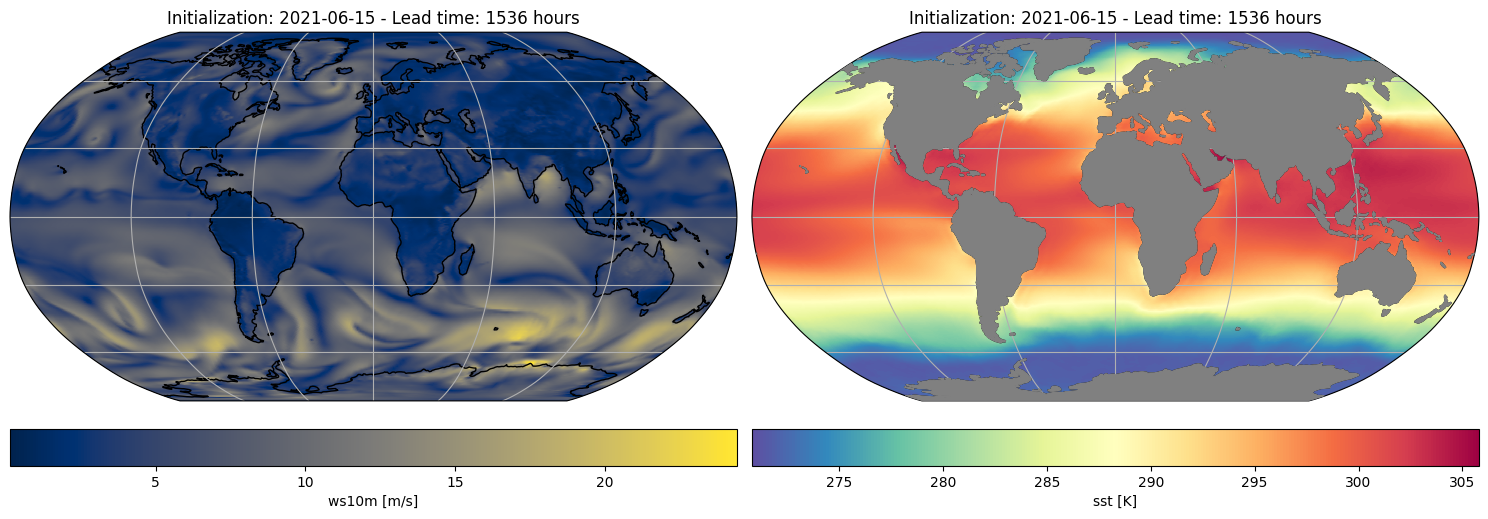

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# lat = x_atmos_coords["lat"]
# lon = x_atmos_coords["lon"]
atmos_var, atmos_units = "ws10m", "m/s"
ocean_var, ocean_units = "sst", "K"
# atmos_var_idx = list(x_atmos_coords["variable"]).index(atmos_var)
# ocean_var_idx = list(x_ocean_coords["variable"]).index(ocean_var)
lead_time = ds.lead_time.values[-1]

plt.close("all")
# สร้างโรบินสัน projection
projection = ccrs.Robinson()

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, axs = plt.subplots(1, 2, subplot_kw={"projection": projection}, figsize=(15, 6))

# พล็อตฟิลด์โดยใช้ pcolormesh
im = axs[0].pcolormesh(
    ds.lon.values,
    ds.lat.values,
    ds[atmos_var].sel(time=ic_date, lead_time=lead_time).values,
    transform=ccrs.PlateCarree(),
    cmap="cividis",
)

# ตั้งชื่อเรื่อง
axs[0].set_title(
    f"Initialization: {ic_date} - Lead time: {lead_time.astype('timedelta64[h]')}"
)

# เพิ่มแนวชายฝั่งและเส้นกริด
axs[0].coastlines()
axs[0].gridlines()

cbar = fig.colorbar(im, ax=axs[0], orientation="horizontal", pad=0.05)
cbar.set_label(f"{atmos_var} [{atmos_units}]")

# วาดองค์ประกอบมหาสมุทร
im = axs[1].pcolormesh(
    ds.lon.values,
    ds.lat.values,
    ds[ocean_var].sel(time=ic_date, lead_time=lead_time).values,
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",
)

axs[1].set_title(
    f"Initialization: {ic_date} - Lead time: {lead_time.astype('timedelta64[h]')}"
)

# เพิ่มแนวชายฝั่งและเส้นกริด
axs[1].add_feature(cfeature.LAND, color="grey", zorder=100)
axs[1].coastlines()
axs[1].gridlines()

cbar = fig.colorbar(im, ax=axs[1], orientation="horizontal", pad=0.05)
cbar.set_label(f"{ocean_var} [{ocean_units}]")

plt.tight_layout()
plt.savefig("outputs/14_ws10m_sst_prediction.png")